# HW10-11 - Компьютерное зрение в PyTorch

В этой работе:

- **Часть A**: классификация изображений на датасете `STL10`
  - `C1`: simple CNN без аугментаций
  - `C2`: simple CNN с аугментациями
  - `C3`: pretrained `ResNet18`, обучение только головы
  - `C4`: pretrained `ResNet18`, partial fine-tuning

- **Часть B**: segmentation track
  - pretrained segmentation model из `torchvision`
  - два режима оценки: `V1` и `V2`
  - визуализация масок и базовая метрика

Все результаты сохраняются в `homeworks/HW10-11/artifacts/`.

In [8]:
# 1) Импорты и общие настройки
import json
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms, models
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from torchvision.models import ResNet18_Weights

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu
device: cpu


In [9]:
@dataclass
class RunConfig:
    # paths
    root_dir: str = "homeworks/HW10-11"
    data_dir: str = "./data"

    # reproducibility
    seed: int = 42

    # classification part
    cls_dataset_name: str = "STL10"
    num_classes: int = 10
    image_size: int = 96
    val_ratio: float = 0.2
    batch_size: int = 128 if torch.cuda.is_available() else 64
    num_workers: int = 0

    # epochs
    epochs_cnn: int = 8
    epochs_resnet_head: int = 5
    epochs_resnet_finetune: int = 5

    # optimization
    lr_cnn: float = 1e-3
    lr_resnet_head: float = 1e-3
    lr_resnet_finetune: float = 1e-4
    weight_decay: float = 1e-4

    # segmentation part
    seg_dataset_name: str = "OxfordIIITPet"
    seg_image_size: int = 256
    seg_batch_size: int = 1
    seg_num_examples_show: int = 4
    seg_threshold_v1: float = 0.5
    seg_threshold_v2: float = 0.6
    seg_remove_small_objects_min_area: int = 300

cfg = RunConfig()
cfg

RunConfig(root_dir='homeworks/HW10-11', data_dir='./data', seed=42, cls_dataset_name='STL10', num_classes=10, image_size=96, val_ratio=0.2, batch_size=64, num_workers=0, epochs_cnn=8, epochs_resnet_head=5, epochs_resnet_finetune=5, lr_cnn=0.001, lr_resnet_head=0.001, lr_resnet_finetune=0.0001, weight_decay=0.0001, seg_dataset_name='OxfordIIITPet', seg_image_size=256, seg_batch_size=1, seg_num_examples_show=4, seg_threshold_v1=0.5, seg_threshold_v2=0.6, seg_remove_small_objects_min_area=300)

In [10]:
# 3) Пути к артефактам
ROOT = Path(cfg.root_dir)
ARTIFACTS = ROOT / "artifacts"
FIGURES = ARTIFACTS / "figures"

ARTIFACTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

RUNS_CSV_PATH = ARTIFACTS / "runs.csv"
BEST_MODEL_PATH = ARTIFACTS / "best_classifier.pt"
BEST_CONFIG_PATH = ARTIFACTS / "best_classifier_config.json"

print("ROOT:", ROOT)
print("ARTIFACTS:", ARTIFACTS)
print("FIGURES:", FIGURES)
print("RUNS_CSV_PATH:", RUNS_CSV_PATH)

ROOT: homeworks\HW10-11
ARTIFACTS: homeworks\HW10-11\artifacts
FIGURES: homeworks\HW10-11\artifacts\figures
RUNS_CSV_PATH: homeworks\HW10-11\artifacts\runs.csv


## Часть A — классификация изображений

Для части A выбираем датасет `STL10`.

Дальше подготовим:
- transforms для simple CNN без аугментаций;
- transforms для simple CNN с аугментациями;
- transforms для pretrained `ResNet18`;
- train / val / test loaders;
- sanity-check данных.

In [11]:
# 4) Transforms для части A
STL10_MEAN = (0.5, 0.5, 0.5)
STL10_STD = (0.5, 0.5, 0.5)

basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(cfg.image_size, padding=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

resnet_weights = ResNet18_Weights.DEFAULT
resnet_transform = resnet_weights.transforms()

print("basic_transform:")
print(basic_transform)
print()
print("augment_transform:")
print(augment_transform)
print()
print("resnet_transform:")
print(resnet_transform)

basic_transform:
Compose(
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)

augment_transform:
Compose(
    RandomHorizontalFlip(p=0.5)
    RandomCrop(size=(96, 96), padding=8)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)

resnet_transform:
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


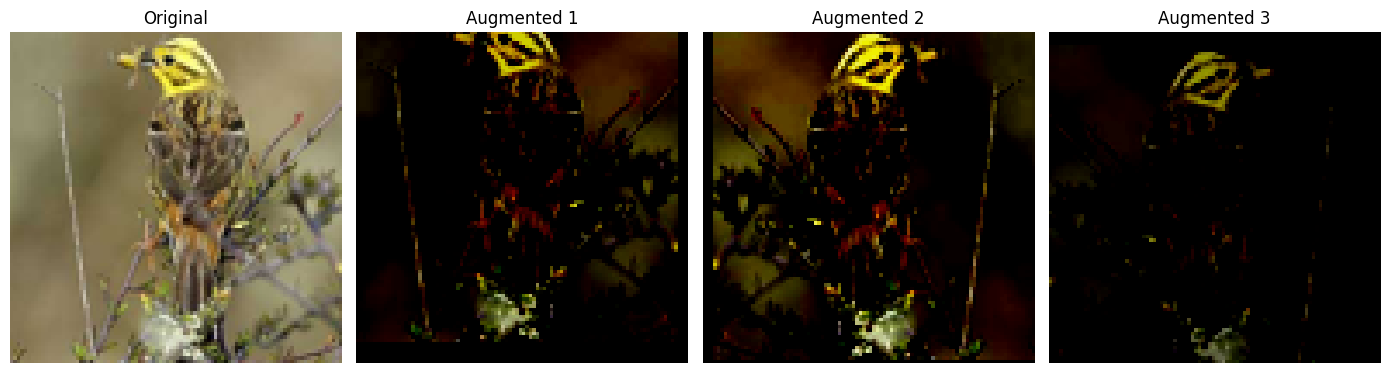

In [12]:
# 5) Визуализация аугментаций
preview_ds = datasets.STL10(
    root=cfg.data_dir,
    split="train",
    download=True,
    transform=None
)

img, label = preview_ds[0]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 4):
    aug_img = augment_transform(img)
    aug_img = aug_img.permute(1, 2, 0).numpy()
    axes[i].imshow(np.clip(aug_img, 0, 1))
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(FIGURES / "augmentations_preview.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# 6) Данные STL10: train / val / test
from torch.utils.data import DataLoader, random_split, Subset

def make_stl10_dataloaders(
    train_transform,
    eval_transform,
    batch_size: int,
    num_workers: int,
    val_ratio: float,
    seed: int,
):
    train_full = datasets.STL10(
        root=cfg.data_dir,
        split="train",
        download=True,
        transform=train_transform
    )

    train_eval_full = datasets.STL10(
        root=cfg.data_dir,
        split="train",
        download=True,
        transform=eval_transform
    )

    test_ds = datasets.STL10(
        root=cfg.data_dir,
        split="test",
        download=True,
        transform=eval_transform
    )

    n_total = len(train_full)
    n_val = int(val_ratio * n_total)
    n_train = n_total - n_val

    generator = torch.Generator().manual_seed(seed)
    train_subset, val_subset = random_split(train_full, [n_train, n_val], generator=generator)

    train_indices = train_subset.indices
    val_indices = val_subset.indices

    train_ds = Subset(train_full, train_indices)
    val_ds = Subset(train_eval_full, val_indices)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

In [14]:
# 7) Sanity-check данных
train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_stl10_dataloaders(
    train_transform=basic_transform,
    eval_transform=basic_transform,
    batch_size=cfg.batch_size,
    num_workers=cfg.num_workers,
    val_ratio=cfg.val_ratio,
    seed=cfg.seed,
)

xb, yb = next(iter(train_loader))
print("x shape:", xb.shape)
print("y shape:", yb.shape)
print("train size:", len(train_ds))
print("val size:", len(val_ds))
print("test size:", len(test_ds))
print("y min / max:", yb.min().item(), yb.max().item())

x shape: torch.Size([64, 3, 96, 96])
y shape: torch.Size([64])
train size: 4000
val size: 1000
test size: 8000
y min / max: 0 9


classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


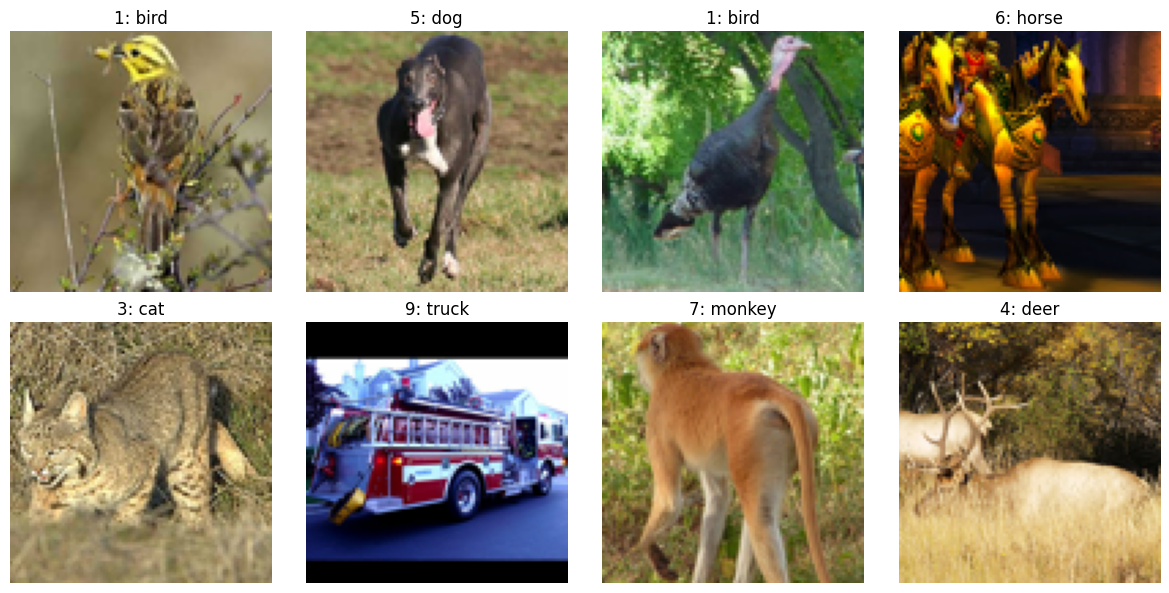

In [15]:
# 8) Несколько примеров из train
classes = preview_ds.classes
print("classes:", classes)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(8):
    img, label = preview_ds[i]
    axes[i].imshow(img)
    axes[i].set_title(f"{label}: {classes[label]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Модели для части A

Дальше определим:
- `SimpleCNN` для экспериментов `C1` и `C2`;
- функцию создания pretrained `ResNet18` для `C3` и `C4`.

In [16]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 96 -> 48

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 48 -> 24

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 24 -> 12
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

simple_cnn = SimpleCNN(num_classes=cfg.num_classes).to(DEVICE)
print(simple_cnn)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [17]:
# 10) Pretrained ResNet18 для C3 / C4
def build_resnet18_classifier(num_classes: int = 10, mode: str = "head_only"):
    """
    mode:
    - 'head_only': frozen backbone, train only fc
    - 'partial_finetune': train layer4 + fc
    """
    model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

    # сначала всё замораживаем
    for p in model.parameters():
        p.requires_grad = False

    # заменяем голову
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    if mode == "head_only":
        for p in model.fc.parameters():
            p.requires_grad = True

    elif mode == "partial_finetune":
        for p in model.layer4.parameters():
            p.requires_grad = True
        for p in model.fc.parameters():
            p.requires_grad = True

    else:
        raise ValueError(f"Unknown mode: {mode}")

    return model.to(DEVICE)

resnet_head = build_resnet18_classifier(num_classes=cfg.num_classes, mode="head_only")
resnet_finetune = build_resnet18_classifier(num_classes=cfg.num_classes, mode="partial_finetune")

print("ResNet18 builders are ready.")

ResNet18 builders are ready.


In [18]:
# 11) Вспомогательные функции
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def append_run_to_csv(row: Dict, csv_path: Path = RUNS_CSV_PATH) -> None:
    row_df = pd.DataFrame([row])

    if csv_path.exists():
        old_df = pd.read_csv(csv_path)
        new_df = pd.concat([old_df, row_df], ignore_index=True)
    else:
        new_df = row_df

    new_df.to_csv(csv_path, index=False)

def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_summary_str(model_name: str, extra: str = "") -> str:
    if extra:
        return f"{model_name} | {extra}"
    return model_name

## Базовые функции обучения и оценки

Для части A реализуем:
- `train_one_epoch(...)`
- `evaluate(...)`
- `fit(...)`

Будем логировать:
- `train_loss`
- `val_loss`
- `train_acc`
- `val_acc`

Лучшую модель для части A позже выберем по `best_val_accuracy`.

In [19]:
# 12) Базовые функции обучения и оценки

def train_one_epoch(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
):
    model.train()

    losses = []
    accs = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits, yb))

    return float(np.mean(losses)), float(np.mean(accs))


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    criterion: nn.Module,
    device: torch.device,
):
    model.eval()

    losses = []
    accs = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits, yb))

    return float(np.mean(losses)), float(np.mean(accs))


def fit(
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    epochs: int,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    best_state = None
    best_val_acc = -1.0
    best_epoch = -1

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
        )

        val_loss, val_acc = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(
            f"Epoch {epoch:02d}/{epochs:02d} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )

    return {
        "history": history,
        "best_val_acc": best_val_acc,
        "best_val_loss": float(np.min(history["val_loss"])),
        "best_epoch": best_epoch,
        "best_state_dict": best_state,
    }

In [20]:
# 13) Графики истории обучения

def plot_history(history: Dict[str, List[float]], title: str = "", save_path: Optional[Path] = None):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

In [21]:
# 14) Helper для экспериментов классификации

def run_classification_experiment(
    experiment_id: str,
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    epochs: int,
    model_summary: str,
    lr: float,
    notes: str = "",
):
    print("\n" + "=" * 90)
    print(f"Running {experiment_id}")
    print("=" * 90)
    print("model_summary:", model_summary)
    print("trainable params:", count_trainable_params(model))

    result = fit(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE,
        epochs=epochs,
    )

    history = result["history"]

    row = {
        "experiment_id": experiment_id,
        "task": "classification",
        "dataset": cfg.cls_dataset_name,
        "seed": cfg.seed,
        "model_summary": model_summary,
        "optimizer": optimizer.__class__.__name__,
        "lr": lr,
        "epochs_trained": epochs,
        "best_val_accuracy": result["best_val_acc"],
        "test_accuracy": np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "mean_iou": np.nan,
        "notes": notes,
    }
    append_run_to_csv(row)

    print(f"{experiment_id} done.")
    print(f"best_epoch      = {result['best_epoch']}")
    print(f"best_val_acc    = {result['best_val_acc']:.4f}")
    print(f"best_val_loss   = {result['best_val_loss']:.4f}")

    return {
        "experiment_id": experiment_id,
        "model": model,
        "history": history,
        "best_epoch": result["best_epoch"],
        "best_val_acc": result["best_val_acc"],
        "best_val_loss": result["best_val_loss"],
        "best_state_dict": result["best_state_dict"],
        "model_summary": model_summary,
        "optimizer_name": optimizer.__class__.__name__,
        "lr": lr,
        "notes": notes,
        "epochs_trained": epochs,
    }

## Эксперимент C1 — simple CNN без аугментаций

В `C1` используем:
- `SimpleCNN`
- базовые transforms без augmentation
- `CrossEntropyLoss`
- `Adam`

Это baseline для сравнения.


Running C1
model_summary: SimpleCNN | base_transform
trainable params: 4814666
Epoch 01/08 | train_loss=1.8533 | train_acc=0.3135 | val_loss=1.5394 | val_acc=0.4178
Epoch 02/08 | train_loss=1.4606 | train_acc=0.4514 | val_loss=1.3957 | val_acc=0.4807
Epoch 03/08 | train_loss=1.2407 | train_acc=0.5422 | val_loss=1.2902 | val_acc=0.5301
Epoch 04/08 | train_loss=1.0470 | train_acc=0.6049 | val_loss=1.2577 | val_acc=0.5510
Epoch 05/08 | train_loss=0.8651 | train_acc=0.6942 | val_loss=1.2642 | val_acc=0.5732
Epoch 06/08 | train_loss=0.6728 | train_acc=0.7550 | val_loss=1.3350 | val_acc=0.5639
Epoch 07/08 | train_loss=0.4628 | train_acc=0.8388 | val_loss=1.4259 | val_acc=0.5871
Epoch 08/08 | train_loss=0.3224 | train_acc=0.8879 | val_loss=1.5178 | val_acc=0.5852
C1 done.
best_epoch      = 7
best_val_acc    = 0.5871
best_val_loss   = 1.2577


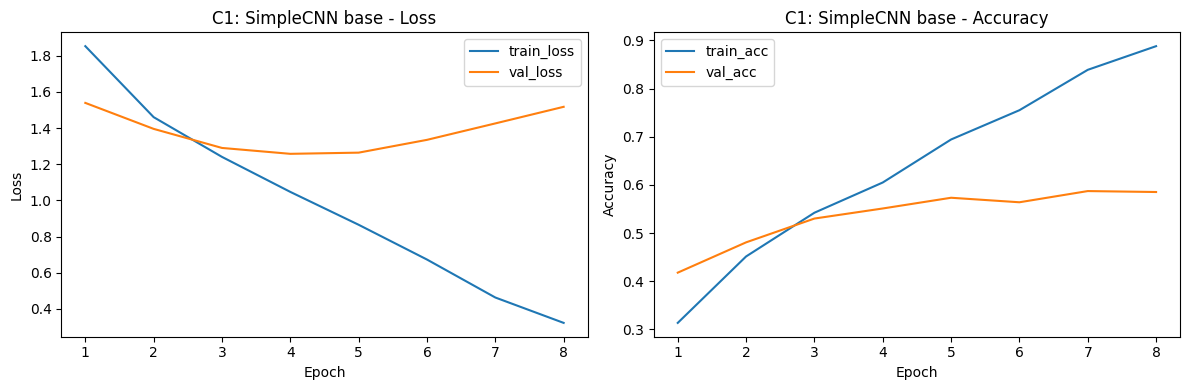

In [22]:
# 15) C1 — simple-cnn-base

train_ds_c1, val_ds_c1, test_ds_c1, train_loader_c1, val_loader_c1, test_loader_c1 = make_stl10_dataloaders(
    train_transform=basic_transform,
    eval_transform=basic_transform,
    batch_size=cfg.batch_size,
    num_workers=cfg.num_workers,
    val_ratio=cfg.val_ratio,
    seed=cfg.seed,
)

model_c1 = SimpleCNN(num_classes=cfg.num_classes).to(DEVICE)
criterion_c1 = nn.CrossEntropyLoss()
optimizer_c1 = optim.Adam(
    model_c1.parameters(),
    lr=cfg.lr_cnn,
    weight_decay=cfg.weight_decay,
)

res_c1 = run_classification_experiment(
    experiment_id="C1",
    model=model_c1,
    train_loader=train_loader_c1,
    val_loader=val_loader_c1,
    optimizer=optimizer_c1,
    criterion=criterion_c1,
    epochs=cfg.epochs_cnn,
    model_summary=model_summary_str("SimpleCNN", "base_transform"),
    lr=cfg.lr_cnn,
    notes="SimpleCNN without augmentations",
)

plot_history(res_c1["history"], title="C1: SimpleCNN base")

## Эксперимент C2 — simple CNN с аугментациями

В `C2` используем ту же архитектуру `SimpleCNN`, что и в `C1`,
но меняем train transforms: добавляем разумные аугментации.

Это нужно, чтобы корректно показать эффект augmentation.


Running C2
model_summary: SimpleCNN | augment_transform
trainable params: 4814666
Epoch 01/08 | train_loss=2.0024 | train_acc=0.2520 | val_loss=1.6570 | val_acc=0.3625
Epoch 02/08 | train_loss=1.6681 | train_acc=0.3641 | val_loss=1.4936 | val_acc=0.4398
Epoch 03/08 | train_loss=1.5320 | train_acc=0.4263 | val_loss=1.4103 | val_acc=0.4834
Epoch 04/08 | train_loss=1.4214 | train_acc=0.4643 | val_loss=1.2632 | val_acc=0.5375
Epoch 05/08 | train_loss=1.3542 | train_acc=0.4963 | val_loss=1.2629 | val_acc=0.5139
Epoch 06/08 | train_loss=1.2894 | train_acc=0.5196 | val_loss=1.1658 | val_acc=0.5611
Epoch 07/08 | train_loss=1.2327 | train_acc=0.5479 | val_loss=1.1541 | val_acc=0.5650
Epoch 08/08 | train_loss=1.1586 | train_acc=0.5826 | val_loss=1.1977 | val_acc=0.5420
C2 done.
best_epoch      = 7
best_val_acc    = 0.5650
best_val_loss   = 1.1541


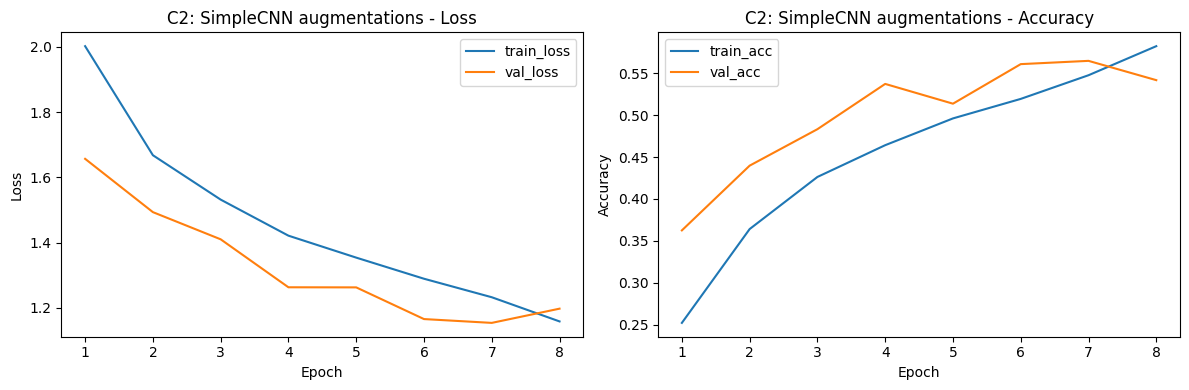

In [23]:
# 16) C2 — simple-cnn-aug

train_ds_c2, val_ds_c2, test_ds_c2, train_loader_c2, val_loader_c2, test_loader_c2 = make_stl10_dataloaders(
    train_transform=augment_transform,
    eval_transform=basic_transform,
    batch_size=cfg.batch_size,
    num_workers=cfg.num_workers,
    val_ratio=cfg.val_ratio,
    seed=cfg.seed,
)

model_c2 = SimpleCNN(num_classes=cfg.num_classes).to(DEVICE)
criterion_c2 = nn.CrossEntropyLoss()
optimizer_c2 = optim.Adam(
    model_c2.parameters(),
    lr=cfg.lr_cnn,
    weight_decay=cfg.weight_decay,
)

res_c2 = run_classification_experiment(
    experiment_id="C2",
    model=model_c2,
    train_loader=train_loader_c2,
    val_loader=val_loader_c2,
    optimizer=optimizer_c2,
    criterion=criterion_c2,
    epochs=cfg.epochs_cnn,
    model_summary=model_summary_str("SimpleCNN", "augment_transform"),
    lr=cfg.lr_cnn,
    notes="Same SimpleCNN as C1, only train augmentations changed",
)

plot_history(res_c2["history"], title="C2: SimpleCNN augmentations")

In [24]:
# 17) Первое сравнение C1 и C2
compare_c12 = pd.DataFrame([
    {
        "experiment_id": res_c1["experiment_id"],
        "best_val_acc": res_c1["best_val_acc"],
        "best_val_loss": res_c1["best_val_loss"],
        "best_epoch": res_c1["best_epoch"],
    },
    {
        "experiment_id": res_c2["experiment_id"],
        "best_val_acc": res_c2["best_val_acc"],
        "best_val_loss": res_c2["best_val_loss"],
        "best_epoch": res_c2["best_epoch"],
    },
])

compare_c12 = compare_c12.sort_values("best_val_acc", ascending=False).reset_index(drop=True)
compare_c12

,experiment_id,best_val_acc,best_val_loss,best_epoch
0,C1,0.587109,1.257676,7
1,C2,0.565039,1.154098,7


## Эксперимент C3 — pretrained ResNet18, обучение только головы

В `C3` используем pretrained `ResNet18` из `torchvision`.

Стратегия:
- backbone заморожен;
- обучается только `fc`-слой;
- preprocessing берём из `ResNet18_Weights.DEFAULT.transforms()`.


Running C3
model_summary: ResNet18 | pretrained, fc_only
trainable params: 5130
Epoch 01/05 | train_loss=1.0548 | train_acc=0.7418 | val_loss=0.4719 | val_acc=0.9135
Epoch 02/05 | train_loss=0.3749 | train_acc=0.9256 | val_loss=0.3213 | val_acc=0.9213
Epoch 03/05 | train_loss=0.2774 | train_acc=0.9325 | val_loss=0.2695 | val_acc=0.9311
Epoch 04/05 | train_loss=0.2348 | train_acc=0.9375 | val_loss=0.2461 | val_acc=0.9277
Epoch 05/05 | train_loss=0.2032 | train_acc=0.9497 | val_loss=0.2332 | val_acc=0.9307
C3 done.
best_epoch      = 3
best_val_acc    = 0.9311
best_val_loss   = 0.2332


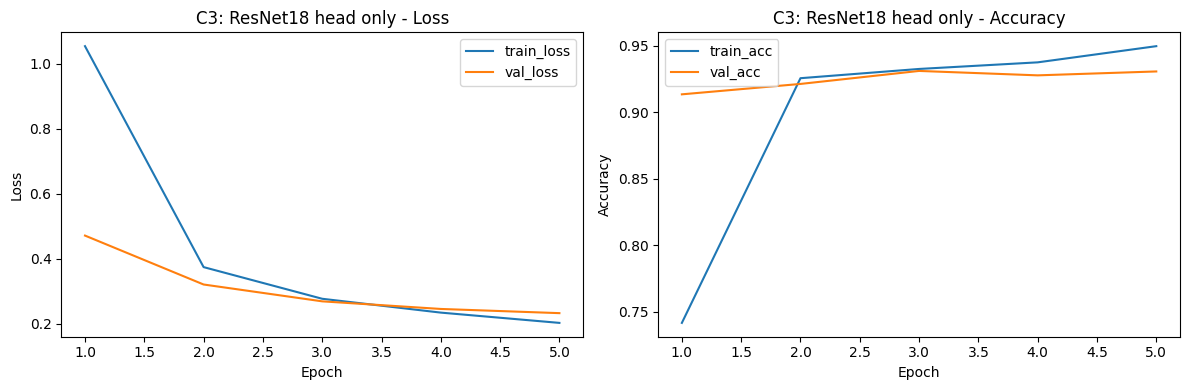

In [25]:
# 18) C3 — resnet18-head-only

train_ds_c3, val_ds_c3, test_ds_c3, train_loader_c3, val_loader_c3, test_loader_c3 = make_stl10_dataloaders(
    train_transform=resnet_transform,
    eval_transform=resnet_transform,
    batch_size=cfg.batch_size,
    num_workers=cfg.num_workers,
    val_ratio=cfg.val_ratio,
    seed=cfg.seed,
)

model_c3 = build_resnet18_classifier(
    num_classes=cfg.num_classes,
    mode="head_only"
).to(DEVICE)

criterion_c3 = nn.CrossEntropyLoss()

optimizer_c3 = optim.Adam(
    filter(lambda p: p.requires_grad, model_c3.parameters()),
    lr=cfg.lr_resnet_head,
    weight_decay=cfg.weight_decay,
)

res_c3 = run_classification_experiment(
    experiment_id="C3",
    model=model_c3,
    train_loader=train_loader_c3,
    val_loader=val_loader_c3,
    optimizer=optimizer_c3,
    criterion=criterion_c3,
    epochs=cfg.epochs_resnet_head,
    model_summary=model_summary_str("ResNet18", "pretrained, fc_only"),
    lr=cfg.lr_resnet_head,
    notes="Pretrained ResNet18, frozen backbone, train fc only",
)

plot_history(res_c3["history"], title="C3: ResNet18 head only")

## Эксперимент C4 — pretrained ResNet18, partial fine-tuning

В `C4` также используем pretrained `ResNet18`, но теперь:
- размораживаем `layer4`;
- обучаем `layer4 + fc`.

Это и есть partial fine-tuning.


Running C4
model_summary: ResNet18 | pretrained, layer4+fc
trainable params: 8398858
Epoch 01/05 | train_loss=0.6345 | train_acc=0.8175 | val_loss=0.2551 | val_acc=0.9271
Epoch 02/05 | train_loss=0.1200 | train_acc=0.9792 | val_loss=0.2071 | val_acc=0.9453
Epoch 03/05 | train_loss=0.0403 | train_acc=0.9988 | val_loss=0.1856 | val_acc=0.9482
Epoch 04/05 | train_loss=0.0196 | train_acc=0.9998 | val_loss=0.1886 | val_acc=0.9473
Epoch 05/05 | train_loss=0.0117 | train_acc=0.9998 | val_loss=0.1782 | val_acc=0.9512
C4 done.
best_epoch      = 5
best_val_acc    = 0.9512
best_val_loss   = 0.1782


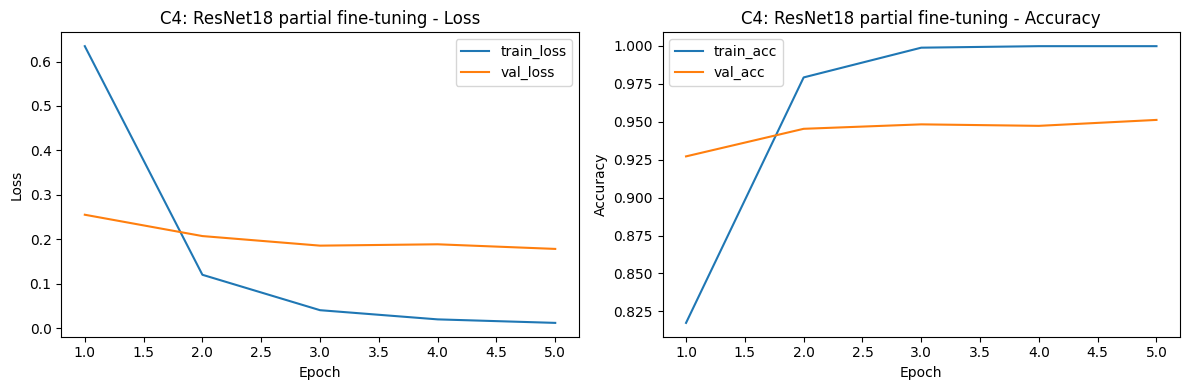

In [26]:
# 19) C4 — resnet18-partial-finetune

train_ds_c4, val_ds_c4, test_ds_c4, train_loader_c4, val_loader_c4, test_loader_c4 = make_stl10_dataloaders(
    train_transform=resnet_transform,
    eval_transform=resnet_transform,
    batch_size=cfg.batch_size,
    num_workers=cfg.num_workers,
    val_ratio=cfg.val_ratio,
    seed=cfg.seed,
)

model_c4 = build_resnet18_classifier(
    num_classes=cfg.num_classes,
    mode="partial_finetune"
).to(DEVICE)

criterion_c4 = nn.CrossEntropyLoss()

optimizer_c4 = optim.Adam(
    filter(lambda p: p.requires_grad, model_c4.parameters()),
    lr=cfg.lr_resnet_finetune,
    weight_decay=cfg.weight_decay,
)

res_c4 = run_classification_experiment(
    experiment_id="C4",
    model=model_c4,
    train_loader=train_loader_c4,
    val_loader=val_loader_c4,
    optimizer=optimizer_c4,
    criterion=criterion_c4,
    epochs=cfg.epochs_resnet_finetune,
    model_summary=model_summary_str("ResNet18", "pretrained, layer4+fc"),
    lr=cfg.lr_resnet_finetune,
    notes="Pretrained ResNet18, partial fine-tuning: layer4 + fc",
)

plot_history(res_c4["history"], title="C4: ResNet18 partial fine-tuning")

## Сравнение экспериментов C1-C4

Теперь сравним все четыре эксперимента по `best_val_accuracy`
и выберем лучший классификатор части A.

In [27]:
# 20) Сводная таблица C1-C4
classification_results = [res_c1, res_c2, res_c3, res_c4]

compare_cls = pd.DataFrame([
    {
        "experiment_id": r["experiment_id"],
        "model_summary": r["model_summary"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
        "best_epoch": r["best_epoch"],
        "optimizer": r["optimizer_name"],
        "lr": r["lr"],
        "epochs_trained": r["epochs_trained"],
        "notes": r["notes"],
    }
    for r in classification_results
])

compare_cls = compare_cls.sort_values("best_val_acc", ascending=False).reset_index(drop=True)
compare_cls

,experiment_id,model_summary,best_val_acc,best_val_loss,best_epoch,optimizer,lr,epochs_trained,notes
0,C4,"ResNet18 | pretrained, layer4+fc",0.951172,0.178204,5,Adam,0.0001,5,"Pretrained ResNet18, partial fine-tuning: laye..."
1,C3,"ResNet18 | pretrained, fc_only",0.931055,0.233183,3,Adam,0.0010,5,"Pretrained ResNet18, frozen backbone, train fc..."
2,C1,SimpleCNN | base_transform,0.587109,1.257676,7,Adam,0.0010,8,SimpleCNN without augmentations
3,C2,SimpleCNN | augment_transform,0.565039,1.154098,7,Adam,0.0010,8,"Same SimpleCNN as C1, only train augmentations..."


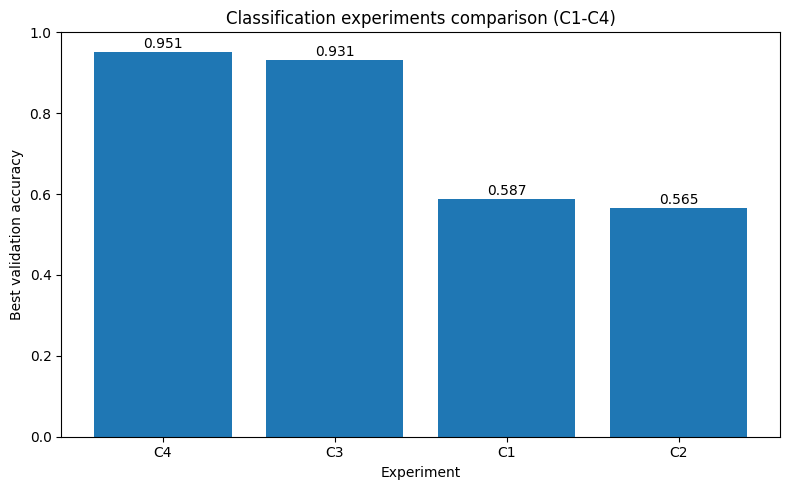

In [28]:
# 21) График сравнения C1-C4
plt.figure(figsize=(8, 5))
plt.bar(compare_cls["experiment_id"], compare_cls["best_val_acc"])
plt.xlabel("Experiment")
plt.ylabel("Best validation accuracy")
plt.title("Classification experiments comparison (C1-C4)")
plt.ylim(0, 1)

for i, v in enumerate(compare_cls["best_val_acc"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.savefig(FIGURES / "classification_compare.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
# 22) Выбор лучшего классификатора по best_val_acc
best_cls_result = max(classification_results, key=lambda x: x["best_val_acc"])

print("Best classification experiment:")
print("experiment_id :", best_cls_result["experiment_id"])
print("model_summary :", best_cls_result["model_summary"])
print("best_val_acc  :", round(best_cls_result["best_val_acc"], 4))
print("best_val_loss :", round(best_cls_result["best_val_loss"], 4))
print("best_epoch    :", best_cls_result["best_epoch"])

Best classification experiment:
experiment_id : C4
model_summary : ResNet18 | pretrained, layer4+fc
best_val_acc  : 0.9512
best_val_loss : 0.1782
best_epoch    : 5


In [30]:
# 23) Восстановление лучших весов в лучшую модель
best_model = best_cls_result["model"]
best_model.load_state_dict(best_cls_result["best_state_dict"])
best_model = best_model.to(DEVICE)
best_model.eval()

print("Best model restored.")

Best model restored.


In [31]:
# 24) Test loader для лучшей модели
if best_cls_result["experiment_id"] in ["C1", "C2"]:
    best_test_loader = test_loader_c1 if best_cls_result["experiment_id"] == "C1" else test_loader_c2
elif best_cls_result["experiment_id"] == "C3":
    best_test_loader = test_loader_c3
elif best_cls_result["experiment_id"] == "C4":
    best_test_loader = test_loader_c4
else:
    raise ValueError("Unknown best classification experiment")

print("Best test loader is ready for:", best_cls_result["experiment_id"])

Best test loader is ready for: C4


In [32]:
# 25) Финальная оценка лучшей модели на test (один раз)
test_criterion = nn.CrossEntropyLoss()
best_test_loss, best_test_acc = evaluate(
    model=best_model,
    loader=best_test_loader,
    criterion=test_criterion,
    device=DEVICE,
)

print(f"FINAL TEST | loss={best_test_loss:.4f} | acc={best_test_acc:.4f}")

FINAL TEST | loss=0.1578 | acc=0.9516


In [33]:
# 26) Обновить runs.csv: записать final test accuracy только для лучшего классификатора
runs_df = pd.read_csv(RUNS_CSV_PATH)

mask = runs_df["experiment_id"] == best_cls_result["experiment_id"]
runs_df.loc[mask, "test_accuracy"] = best_test_acc

runs_df.to_csv(RUNS_CSV_PATH, index=False)

runs_df

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,SimpleCNN | base_transform,Adam,0.0010,8,0.587109,NaN,NaN,NaN,NaN,SimpleCNN without augmentations
1,C2,classification,STL10,42,SimpleCNN | augment_transform,Adam,0.0010,8,0.565039,NaN,NaN,NaN,NaN,"Same SimpleCNN as C1, only train augmentations..."
2,C3,classification,STL10,42,"ResNet18 | pretrained, fc_only",Adam,0.0010,5,0.931055,NaN,NaN,NaN,NaN,"Pretrained ResNet18, frozen backbone, train fc..."
3,C4,classification,STL10,42,"ResNet18 | pretrained, layer4+fc",Adam,0.0001,5,0.951172,0.951625,NaN,NaN,NaN,"Pretrained ResNet18, partial fine-tuning: laye..."


In [34]:
# 27) Сохранить лучшую модель части A
torch.save(best_model.state_dict(), BEST_MODEL_PATH)
print("Saved:", BEST_MODEL_PATH)

Saved: homeworks\HW10-11\artifacts\best_classifier.pt


In [35]:
# 28) Сохранить конфиг лучшей модели
best_transform_name = {
    "C1": "basic_transform",
    "C2": "augment_transform(train) + basic_transform(eval)",
    "C3": "resnet_transform",
    "C4": "resnet_transform",
}[best_cls_result["experiment_id"]]

best_config = {
    "dataset": cfg.cls_dataset_name,
    "experiment_id": best_cls_result["experiment_id"],
    "architecture": best_cls_result["model_summary"],
    "seed": cfg.seed,
    "num_classes": cfg.num_classes,
    "image_size": cfg.image_size,
    "batch_size": cfg.batch_size,
    "optimizer": best_cls_result["optimizer_name"],
    "lr": best_cls_result["lr"],
    "epochs_trained": best_cls_result["epochs_trained"],
    "best_epoch": best_cls_result["best_epoch"],
    "best_val_accuracy": best_cls_result["best_val_acc"],
    "final_test_accuracy": best_test_acc,
    "transform": best_transform_name,
    "weight_decay": cfg.weight_decay,
}

with open(BEST_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

print("Saved:", BEST_CONFIG_PATH)

Saved: homeworks\HW10-11\artifacts\best_classifier_config.json


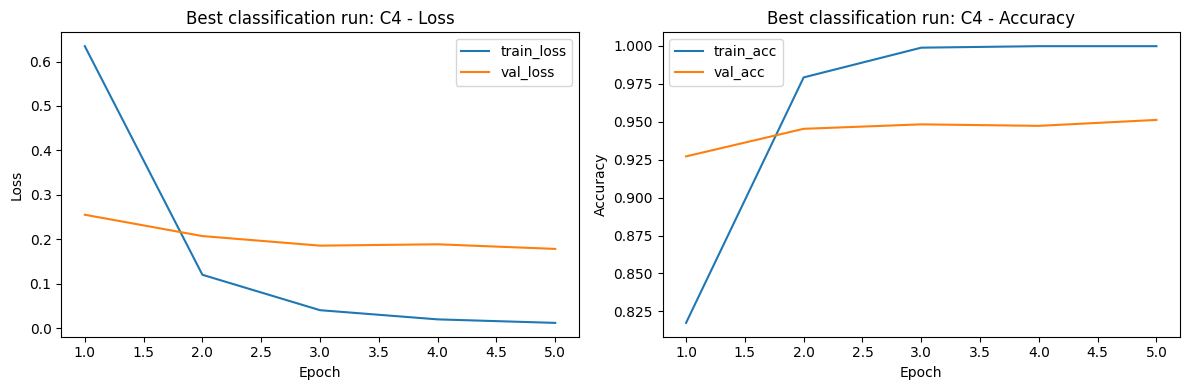

In [36]:
# 29) Сохранить график лучшего классификационного прогона
plot_history(
    best_cls_result["history"],
    title=f"Best classification run: {best_cls_result['experiment_id']}",
    save_path=FIGURES / "classification_curves_best.png",
)

### Краткий вывод по части A

После экспериментов `C1-C4` выбран лучший классификатор по `best_val_accuracy`.
Только после этого выполнена единственная финальная оценка на `test`.

Сохранены:
- `artifacts/best_classifier.pt`
- `artifacts/best_classifier_config.json`
- `artifacts/figures/classification_compare.png`
- `artifacts/figures/classification_curves_best.png`

## Часть B — segmentation track

Во второй части выбираем **segmentation**.

Идея:
- используем pretrained segmentation model из `torchvision`;
- берём датасет `OxfordIIITPet`;
- рассматриваем один понятный foreground-сценарий: **pet vs background**;
- считаем бинарные метрики:
  - `mean_iou`
  - `precision`
  - `recall`

Сделаем два режима:
- `V1`: базовая бинаризация маски
- `V2`: альтернативная постобработка

In [37]:
# 30) Дополнительные параметры для segmentation
print("seg_image_size:", cfg.seg_image_size)
print("seg_threshold_v1:", cfg.seg_threshold_v1)
print("seg_threshold_v2:", cfg.seg_threshold_v2)

seg_image_size: 256
seg_threshold_v1: 0.5
seg_threshold_v2: 0.6


In [38]:
# 31) Dataset для OxfordIIITPet: image + binary pet mask
import torch.utils.data
from torchvision.datasets import OxfordIIITPet

class OxfordPetSegDataset(torch.utils.data.Dataset):
    def __init__(self, root: str, split: str = "test", image_size: int = 256):
        self.root = root
        self.split = split
        self.image_size = image_size

        self.ds = OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True,
        )

        self.image_resize = transforms.Resize(
            (image_size, image_size),
            interpolation=InterpolationMode.BILINEAR
        )
        self.mask_resize = transforms.Resize(
            (image_size, image_size),
            interpolation=InterpolationMode.NEAREST
        )

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx: int):
        img_pil, trimap_pil = self.ds[idx]   # PIL image, PIL mask

        img_rs = self.image_resize(img_pil)
        trimap_rs = self.mask_resize(trimap_pil)

        # image -> tensor [3,H,W]
        img_tensor = TF.to_tensor(img_rs)

        # trimap values in OxfordIIITPet:
        # 1 = foreground (pet)
        # 2 = background
        # 3 = border
        trimap_np = np.array(trimap_rs, dtype=np.uint8)

        # foreground-сценарий: pet vs background
        # border тоже относим к pet, чтобы не терять контур животного
        gt_mask = np.isin(trimap_np, [1, 3]).astype(np.uint8)

        return {
            "image_pil": img_rs,
            "image_tensor": img_tensor,
            "gt_mask": gt_mask,   # numpy [H,W], 0/1
            "idx": idx,
        }

seg_dataset = OxfordPetSegDataset(
    root=cfg.data_dir,
    split="test",
    image_size=cfg.seg_image_size,
)

print("seg_dataset size:", len(seg_dataset))
sample = seg_dataset[0]
print("image_tensor shape:", sample["image_tensor"].shape)
print("gt_mask shape:", sample["gt_mask"].shape)
print("gt unique values:", np.unique(sample["gt_mask"]))

seg_dataset size: 3669
image_tensor shape: torch.Size([3, 256, 256])
gt_mask shape: (256, 256)
gt unique values: [0 1]


### Выбор pretrained segmentation model

Для части B нам не нужно обучать новую модель.  
Нужен корректный pretrained pipeline, визуализация и честная метрика.

Используем `DeepLabV3_ResNet50` из `torchvision`.

In [39]:
# 32) Pretrained segmentation model
from torchvision.models.segmentation import (
    deeplabv3_resnet50,
    DeepLabV3_ResNet50_Weights,
)

seg_weights = DeepLabV3_ResNet50_Weights.DEFAULT
seg_model = deeplabv3_resnet50(weights=seg_weights).to(DEVICE)
seg_model.eval()

seg_preprocess = seg_weights.transforms()

print("Segmentation model is ready.")
print("categories:", seg_weights.meta.get("categories", None))

Segmentation model is ready.
categories: ['__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


In [40]:
# 33) Предсказание binary mask: pet = cat OR dog
seg_categories = seg_weights.meta["categories"]

if "cat" not in seg_categories or "dog" not in seg_categories:
    raise RuntimeError("В pretrained weights не найдены классы 'cat' и 'dog'.")

CAT_IDX = seg_categories.index("cat")
DOG_IDX = seg_categories.index("dog")

print("CAT_IDX:", CAT_IDX)
print("DOG_IDX:", DOG_IDX)

@torch.no_grad()
def predict_pet_prob_mask(img_pil: Image.Image, out_size=None) -> np.ndarray:
    """
    Возвращает вероятностную карту foreground = P(cat) + P(dog)
    shape: [H, W], значения в [0,1]

    out_size: (H, W) — если задан, результат приводится к этому размеру
    """
    x = seg_preprocess(img_pil).unsqueeze(0).to(DEVICE)   # [1,3,H,W]
    logits = seg_model(x)["out"][0]                       # [C,H,W]
    probs = torch.softmax(logits, dim=0)                  # [C,H,W]

    pet_prob = probs[CAT_IDX] + probs[DOG_IDX]            # [H,W]
    pet_prob = pet_prob.clamp(0.0, 1.0).unsqueeze(0).unsqueeze(0)  # [1,1,H,W]

    if out_size is not None:
        pet_prob = torch.nn.functional.interpolate(
            pet_prob,
            size=out_size,
            mode="bilinear",
            align_corners=False,
        )

    pet_prob = pet_prob[0, 0].detach().cpu().numpy()
    return pet_prob

CAT_IDX: 8
DOG_IDX: 12


In [41]:
# 34) Постобработка для V2
def remove_small_connected_components(mask: np.ndarray, min_area: int = 300) -> np.ndarray:
    """
    mask: numpy [H,W], 0/1
    Оставляем только компоненты площадью >= min_area.
    Реализация без внешних библиотек.
    """
    mask = mask.astype(np.uint8)
    h, w = mask.shape

    visited = np.zeros((h, w), dtype=np.uint8)
    out = np.zeros((h, w), dtype=np.uint8)

    neighbors = [(-1,0), (1,0), (0,-1), (0,1)]

    for y in range(h):
        for x in range(w):
            if mask[y, x] == 0 or visited[y, x] == 1:
                continue

            # BFS
            queue = [(y, x)]
            visited[y, x] = 1
            component = [(y, x)]

            head = 0
            while head < len(queue):
                cy, cx = queue[head]
                head += 1

                for dy, dx in neighbors:
                    ny, nx = cy + dy, cx + dx
                    if 0 <= ny < h and 0 <= nx < w:
                        if mask[ny, nx] == 1 and visited[ny, nx] == 0:
                            visited[ny, nx] = 1
                            queue.append((ny, nx))
                            component.append((ny, nx))

            if len(component) >= min_area:
                for py, px in component:
                    out[py, px] = 1

    return out

In [42]:
# 35) Метрики segmentation
def iou_binary(pred: np.ndarray, gt: np.ndarray) -> float:
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    return float(inter / (union + 1e-9))

def precision_binary(pred: np.ndarray, gt: np.ndarray) -> float:
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, np.logical_not(gt)).sum()

    return float(tp / (tp + fp + 1e-9))

def recall_binary(pred: np.ndarray, gt: np.ndarray) -> float:
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = np.logical_and(pred, gt).sum()
    fn = np.logical_and(np.logical_not(pred), gt).sum()

    return float(tp / (tp + fn + 1e-9))

In [43]:
# 36) Два режима: V1 и V2
def make_pred_mask_v1(prob_mask: np.ndarray, threshold: float) -> np.ndarray:
    return (prob_mask >= threshold).astype(np.uint8)

def make_pred_mask_v2(prob_mask: np.ndarray, threshold: float, min_area: int) -> np.ndarray:
    mask = (prob_mask >= threshold).astype(np.uint8)
    mask = remove_small_connected_components(mask, min_area=min_area)
    return mask

In [44]:
# 37) Оценка segmentation на подмножестве или на всём test
def evaluate_segmentation(dataset, mode: str = "V1", max_items: Optional[int] = None):
    ious = []
    precisions = []
    recalls = []

    n = len(dataset) if max_items is None else min(max_items, len(dataset))

    for i in range(n):
        item = dataset[i]
        img_pil = item["image_pil"]
        gt_mask = item["gt_mask"]

        prob_mask = predict_pet_prob_mask(img_pil, out_size=gt_mask.shape)

        if mode == "V1":
            pred_mask = make_pred_mask_v1(
                prob_mask,
                threshold=cfg.seg_threshold_v1,
            )
        elif mode == "V2":
            pred_mask = make_pred_mask_v2(
                prob_mask,
                threshold=cfg.seg_threshold_v2,
                min_area=cfg.seg_remove_small_objects_min_area,
            )
        else:
            raise ValueError(f"Unknown mode: {mode}")

        ious.append(iou_binary(pred_mask, gt_mask))
        precisions.append(precision_binary(pred_mask, gt_mask))
        recalls.append(recall_binary(pred_mask, gt_mask))

    return {
        "n": n,
        "mean_iou": float(np.mean(ious)),
        "mean_precision": float(np.mean(precisions)),
        "mean_recall": float(np.mean(recalls)),
        "all_ious": ious,
        "all_precisions": precisions,
        "all_recalls": recalls,
    }

## Режим V1

`V1` — базовый режим:
- считаем probability map для `cat OR dog`;
- бинаризуем её простым порогом.

In [45]:
# 38) V1
seg_res_v1 = evaluate_segmentation(
    dataset=seg_dataset,
    mode="V1",
    max_items=200,   # можно поставить число, если нужно быстро проверить
)

seg_res_v1

{'n': 200,
 'mean_iou': 0.8149812126431135,
 'mean_precision': 0.980452166699247,
 'mean_recall': 0.8290465198511267,
 'all_ious': [0.8029559461309744,
  0.8576012321118618,
  0.7610287551348115,
  0.8409100310237501,
  0.9427378759975215,
  0.49386558684877035,
  0.7466095645966722,
  0.9055458814838029,
  0.6979462618718768,
  0.8273457774442414,
  0.8727837453086202,
  0.926307602566573,
  0.7725462703308814,
  0.907491877030714,
  0.8552948581598582,
  0.6313627927180574,
  0.8417084180762726,
  0.8988938148323118,
  0.854078934482393,
  0.8971134548870384,
  0.3857017323625166,
  0.8933529659234173,
  0.795445302968657,
  0.9093115041660311,
  0.7878219554888394,
  0.889446335782078,
  0.8186210155962391,
  0.743466137341049,
  0.8859708072363409,
  0.8141506602640445,
  0.7645081783553235,
  0.7979863430194488,
  0.8477997953297718,
  0.8483295032702096,
  0.7650228194725681,
  0.5248913195904834,
  0.79282935903936,
  0.7489408441863526,
  0.9167646307180958,
  0.774419344575184

## Режим V2

`V2` — альтернативная постобработка:
- используем другой threshold;
- удаляем слишком маленькие компоненты.

Это даёт второй корректный режим оценки во второй части.

In [46]:
# 39) V2
seg_res_v2 = evaluate_segmentation(
    dataset=seg_dataset,
    mode="V2",
    max_items=200,
)

seg_res_v2

{'n': 200,
 'mean_iou': 0.7974581252540767,
 'mean_precision': 0.9855812759071554,
 'mean_recall': 0.8079198340938532,
 'all_ious': [0.7735849056603331,
  0.8347261506813555,
  0.7363226296279426,
  0.8297291622926378,
  0.9329253305805209,
  0.5056494507915367,
  0.7416879795395968,
  0.8961532372961614,
  0.6743152918160794,
  0.808483087515371,
  0.8556463531252344,
  0.915072760013605,
  0.7281547952888187,
  0.8910336628707017,
  0.8385822499077369,
  0.6108279487899582,
  0.834901070385967,
  0.8784016534618981,
  0.8347860150817473,
  0.8779535163207745,
  0.32789276288371105,
  0.8822059108271131,
  0.7748474200110681,
  0.8983744591275612,
  0.7771447721179299,
  0.8712800286840771,
  0.8043375518562829,
  0.7231542033930091,
  0.8742775731834932,
  0.8089964869405216,
  0.7429979834191831,
  0.7770522853012621,
  0.8365429342264137,
  0.8297194441985282,
  0.7389072008113121,
  0.48190997055108103,
  0.7893696208420103,
  0.7207532365633016,
  0.9089583546505448,
  0.75684059

In [47]:
# 40) Запись V1 / V2 в runs.csv
append_run_to_csv({
    "experiment_id": "V1",
    "task": "segmentation",
    "dataset": cfg.seg_dataset_name,
    "seed": cfg.seed,
    "model_summary": "DeepLabV3_ResNet50 pretrained; foreground = cat|dog vs background",
    "optimizer": np.nan,
    "lr": np.nan,
    "epochs_trained": 0,
    "best_val_accuracy": np.nan,
    "test_accuracy": np.nan,
    "precision": seg_res_v1["mean_precision"],
    "recall": seg_res_v1["mean_recall"],
    "mean_iou": seg_res_v1["mean_iou"],
    "notes": f"V1: threshold={cfg.seg_threshold_v1}",
})

append_run_to_csv({
    "experiment_id": "V2",
    "task": "segmentation",
    "dataset": cfg.seg_dataset_name,
    "seed": cfg.seed,
    "model_summary": "DeepLabV3_ResNet50 pretrained; foreground = cat|dog vs background",
    "optimizer": np.nan,
    "lr": np.nan,
    "epochs_trained": 0,
    "best_val_accuracy": np.nan,
    "test_accuracy": np.nan,
    "precision": seg_res_v2["mean_precision"],
    "recall": seg_res_v2["mean_recall"],
    "mean_iou": seg_res_v2["mean_iou"],
    "notes": f"V2: threshold={cfg.seg_threshold_v2}, min_area={cfg.seg_remove_small_objects_min_area}",
})

pd.read_csv(RUNS_CSV_PATH)

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,SimpleCNN | base_transform,Adam,0.0010,8,0.587109,NaN,NaN,NaN,NaN,SimpleCNN without augmentations
1,C2,classification,STL10,42,SimpleCNN | augment_transform,Adam,0.0010,8,0.565039,NaN,NaN,NaN,NaN,"Same SimpleCNN as C1, only train augmentations..."
2,C3,classification,STL10,42,"ResNet18 | pretrained, fc_only",Adam,0.0010,5,0.931055,NaN,NaN,NaN,NaN,"Pretrained ResNet18, frozen backbone, train fc..."
3,C4,classification,STL10,42,"ResNet18 | pretrained, layer4+fc",Adam,0.0001,5,0.951172,0.951625,NaN,NaN,NaN,"Pretrained ResNet18, partial fine-tuning: laye..."
4,V1,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50 pretrained; foreground = ca...,NaN,NaN,0,NaN,NaN,0.980452,0.829047,0.814981,V1: threshold=0.5
5,V2,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50 pretrained; foreground = ca...,NaN,NaN,0,NaN,NaN,0.985581,0.807920,0.797458,"V2: threshold=0.6, min_area=300"


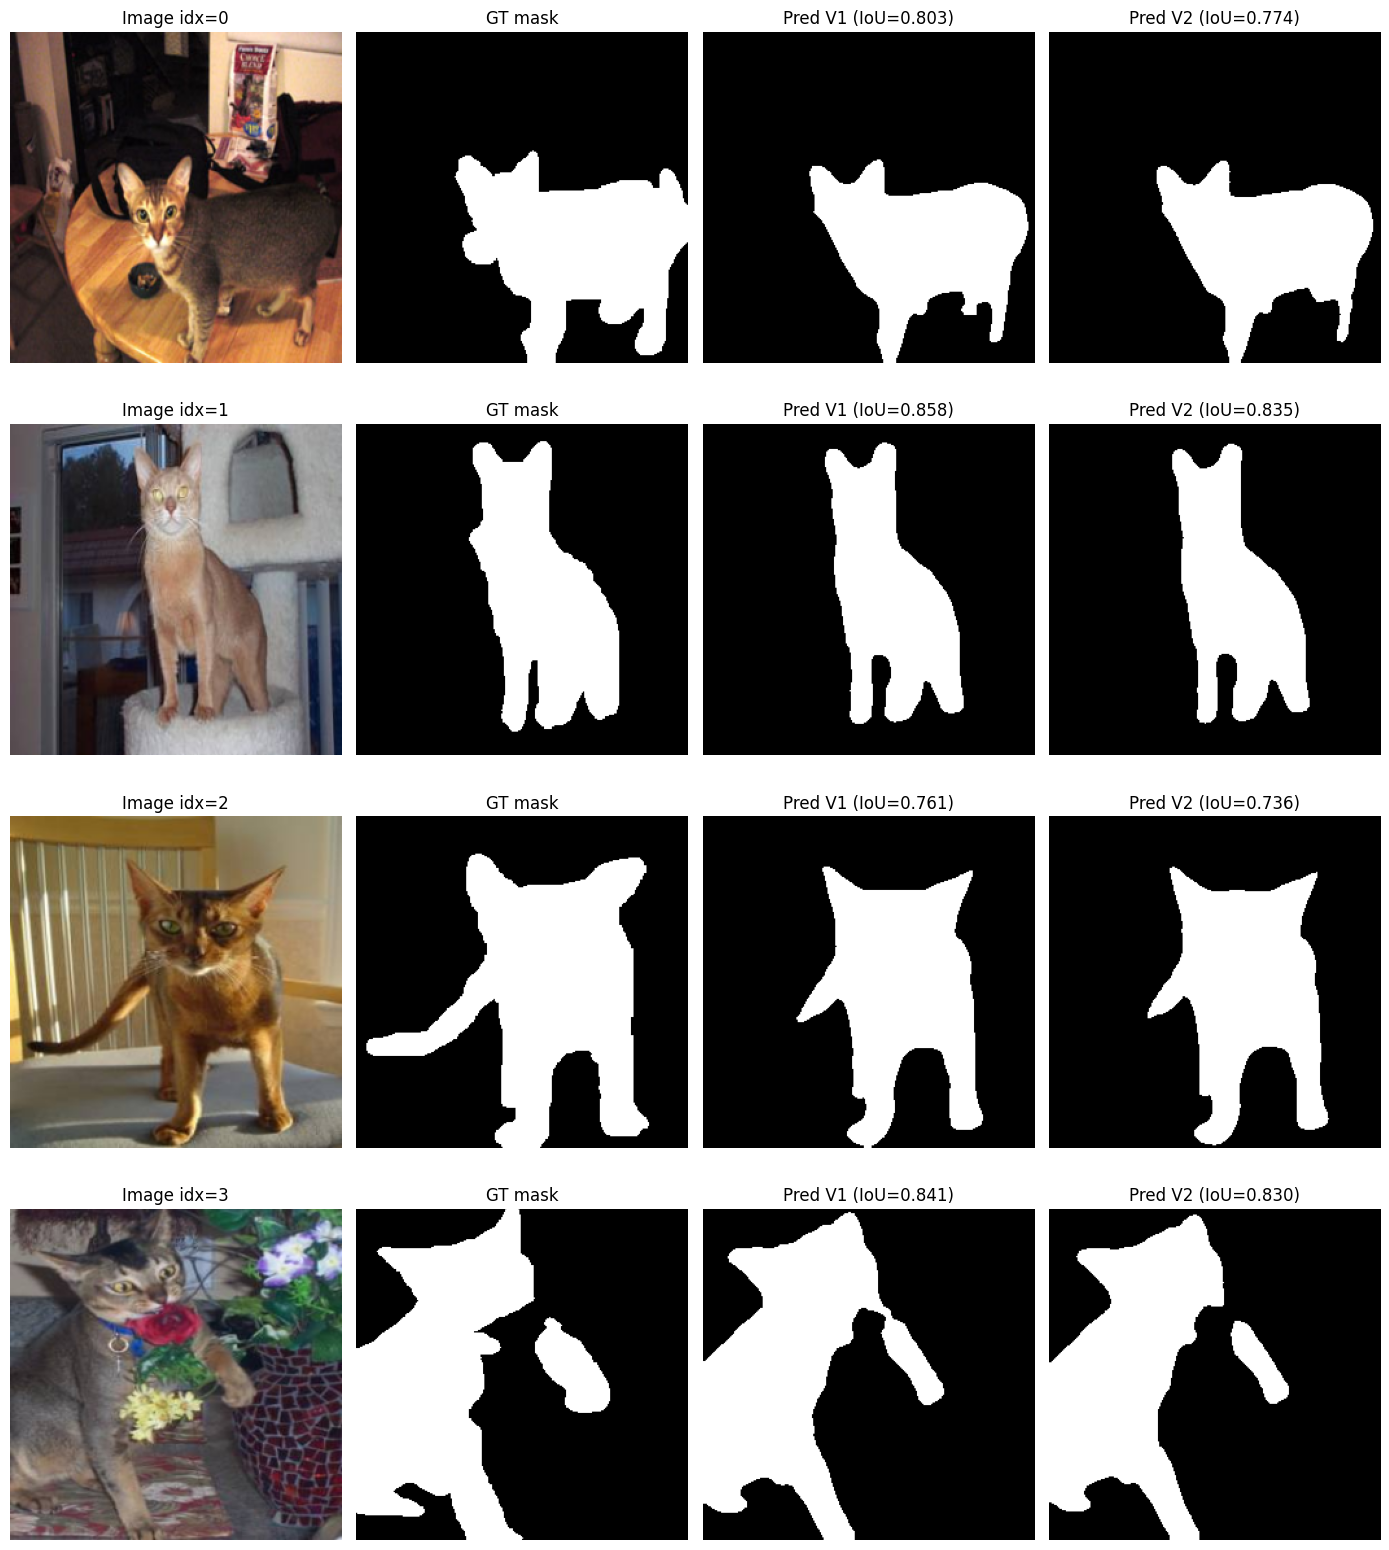

In [48]:
# 41) Визуализация image / GT / pred(V1) / pred(V2)
n_show = min(cfg.seg_num_examples_show, len(seg_dataset))
fig, axes = plt.subplots(n_show, 4, figsize=(14, 4 * n_show))

if n_show == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n_show):
    item = seg_dataset[row]
    img_pil = item["image_pil"]
    gt_mask = item["gt_mask"]

    prob_mask = predict_pet_prob_mask(img_pil, out_size=gt_mask.shape)
    pred_v1 = make_pred_mask_v1(prob_mask, threshold=cfg.seg_threshold_v1)
    pred_v2 = make_pred_mask_v2(
        prob_mask,
        threshold=cfg.seg_threshold_v2,
        min_area=cfg.seg_remove_small_objects_min_area,
    )

    iou_v1 = iou_binary(pred_v1, gt_mask)
    iou_v2 = iou_binary(pred_v2, gt_mask)

    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title(f"Image idx={row}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(gt_mask, cmap="gray")
    axes[row, 1].set_title("GT mask")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pred_v1, cmap="gray")
    axes[row, 2].set_title(f"Pred V1 (IoU={iou_v1:.3f})")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(pred_v2, cmap="gray")
    axes[row, 3].set_title(f"Pred V2 (IoU={iou_v2:.3f})")
    axes[row, 3].axis("off")

plt.tight_layout()
plt.savefig(FIGURES / "segmentation_examples.png", dpi=150, bbox_inches="tight")
plt.show()

In [49]:
# 42) Сравнение метрик V1 vs V2
seg_compare_df = pd.DataFrame([
    {
        "experiment_id": "V1",
        "mean_iou": seg_res_v1["mean_iou"],
        "precision": seg_res_v1["mean_precision"],
        "recall": seg_res_v1["mean_recall"],
    },
    {
        "experiment_id": "V2",
        "mean_iou": seg_res_v2["mean_iou"],
        "precision": seg_res_v2["mean_precision"],
        "recall": seg_res_v2["mean_recall"],
    },
])

seg_compare_df

,experiment_id,mean_iou,precision,recall
0,V1,0.814981,0.980452,0.829047
1,V2,0.797458,0.985581,0.807920


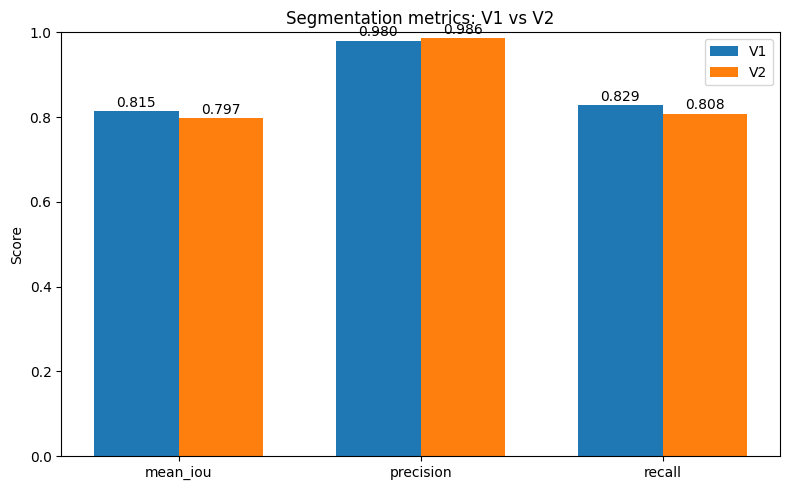

In [50]:
# 43) График метрик segmentation
metrics_names = ["mean_iou", "precision", "recall"]
x = np.arange(len(metrics_names))
width = 0.35

v1_vals = [
    seg_res_v1["mean_iou"],
    seg_res_v1["mean_precision"],
    seg_res_v1["mean_recall"],
]
v2_vals = [
    seg_res_v2["mean_iou"],
    seg_res_v2["mean_precision"],
    seg_res_v2["mean_recall"],
]

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, v1_vals, width, label="V1")
plt.bar(x + width / 2, v2_vals, width, label="V2")

plt.xticks(x, metrics_names)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Segmentation metrics: V1 vs V2")
plt.legend()

for i, v in enumerate(v1_vals):
    plt.text(i - width / 2, v + 0.01, f"{v:.3f}", ha="center")
for i, v in enumerate(v2_vals):
    plt.text(i + width / 2, v + 0.01, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.savefig(FIGURES / "segmentation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


### Краткий вывод по части B

Во второй части выбран `segmentation track`.

Foreground определён как:
- **pet vs background**
- в GT foreground строится по trimap:
  - `1` и `3` считаются foreground,
  - `2` считается background

В pretrained prediction foreground задаётся как объединение классов:
- `cat`
- `dog`

Сравнены два режима:
- `V1`: базовая бинаризация
- `V2`: альтернативная постобработка

Для оценки использованы:
- `mean_iou`
- `precision`
- `recall`